# 04 — Frequency-Aware Gated Temporal Fusion Transformer (FAG-TFT)
### Novel Architecture — Primary Model
> Run 00_Data_Preparation.ipynb first.

In [11]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [12]:
with open('prepared_classification.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train    = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test     = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train    = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test     = torch.LongTensor(d['y_test_seq']).to(DEVICE)
X_ae_train = torch.FloatTensor(d['X_ae_train']).to(DEVICE)
X_ae_test  = torch.FloatTensor(d['X_ae_test']).to(DEVICE)

NUM_CLASSES   = d['num_classes']
NUM_FEATURES  = d['num_features']
TIME_STEPS    = d['TIME_STEPS']
feature_names = d['feature_names']

G1_IDX = list(range(0,  9))
G2_IDX = list(range(9,  29))
G3_IDX = list(range(29, 60))
EL_IDX = list(range(60, 67))  # 6 electrical + 1 time_gap

# ── CLASS WEIGHTS ─────────────────────────────────────────────────────
class_counts   = np.bincount(d['y_train_seq'])
class_weights  = 1.0 / class_counts
class_weights  = class_weights / class_weights.sum() * len(class_counts)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
ae_loader    = DataLoader(TensorDataset(X_ae_train, X_ae_train), batch_size=32, shuffle=True)

print(f'✅ Data loaded.')
print(f'   G1 (10-100Hz)  : {len(G1_IDX)} bands')
print(f'   G2 (100-300Hz) : {len(G2_IDX)} bands')
print(f'   G3 (300-610Hz) : {len(G3_IDX)} bands')
print(f'   Electrical     : {len(EL_IDX)} features')
print(f'   Class counts   : {class_counts}')
print(f'   Class weights  : {class_weights.round(3)}')

✅ Data loaded.
   G1 (10-100Hz)  : 9 bands
   G2 (100-300Hz) : 20 bands
   G3 (300-610Hz) : 31 bands
   Electrical     : 7 features
   Class counts   : [2495  395  800  226]
   Class weights  : [0.186 1.177 0.581 2.056]


---
## Stage 1 — CNN-LSTM Autoencoder (Anomaly Gate)
> Trained on healthy data only.

In [13]:
class AnomalyGate(nn.Module):
    def __init__(self, time_steps, num_features, num_vib=60, num_elec=7):
        super().__init__()
        self.time_steps = time_steps
        self.num_vib    = num_vib
        self.num_elec   = num_elec
        self.enc_vib_conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2)
        )
        enc_vib_size     = 32 * (num_vib // 2)
        self.enc_lstm    = nn.LSTM(enc_vib_size + num_elec, 32, batch_first=True)
        self.bottleneck  = nn.Linear(32, 16)
        self.dec_lstm    = nn.LSTM(16, 32, batch_first=True)
        self.dec_out     = nn.Linear(32, num_features)

    def encode(self, x):
        batch   = x.size(0)
        vib_in  = x[:, :, :self.num_vib]
        elec_in = x[:, :, self.num_vib:]
        vib_feats = []
        for t in range(self.time_steps):
            vt = vib_in[:, t, :].unsqueeze(1)
            vt = self.enc_vib_conv(vt).view(batch, -1)
            vib_feats.append(vt)
        vib_seq  = torch.stack(vib_feats, dim=1)
        merged   = torch.cat([vib_seq, elec_in], dim=2)
        _, (h,_) = self.enc_lstm(merged)
        return self.bottleneck(h[-1])

    def forward(self, x):
        encoded    = self.encode(x)
        repeated   = encoded.unsqueeze(1).repeat(1, self.time_steps, 1)
        dec_out, _ = self.dec_lstm(repeated)
        return self.dec_out(dec_out)

gate = AnomalyGate(TIME_STEPS, NUM_FEATURES).to(DEVICE)
print(f'AnomalyGate parameters: {sum(p.numel() for p in gate.parameters()):,}')

AnomalyGate parameters: 137,459


#### Train Anomaly Gate — 300 epochs for full convergence

Training Anomaly Gate on healthy data only...
Epoch   1 | Train: 0.896942 | Val: 0.914340
Epoch   2 | Train: 0.858900 | Val: 0.891584
Epoch   3 | Train: 0.841298 | Val: 0.880532
Epoch   4 | Train: 0.830938 | Val: 0.872104
Epoch   5 | Train: 0.820791 | Val: 0.865297
Epoch   6 | Train: 0.812275 | Val: 0.856434
Epoch   7 | Train: 0.800450 | Val: 0.844897
Epoch   8 | Train: 0.789810 | Val: 0.838776
Epoch   9 | Train: 0.781476 | Val: 0.831468
Epoch  10 | Train: 0.776516 | Val: 0.830818
Epoch  11 | Train: 0.772066 | Val: 0.825181
Epoch  12 | Train: 0.768792 | Val: 0.821373
Epoch  13 | Train: 0.762894 | Val: 0.820674
Epoch  14 | Train: 0.758298 | Val: 0.814927
Epoch  15 | Train: 0.755043 | Val: 0.810490
Epoch  16 | Train: 0.747745 | Val: 0.804479
Epoch  17 | Train: 0.741056 | Val: 0.799785
Epoch  18 | Train: 0.733179 | Val: 0.795376
Epoch  19 | Train: 0.729058 | Val: 0.786873
Epoch  20 | Train: 0.722259 | Val: 0.782015
Epoch  21 | Train: 0.716478 | Val: 0.778809
Epoch  22 | Train: 0.713815 | 

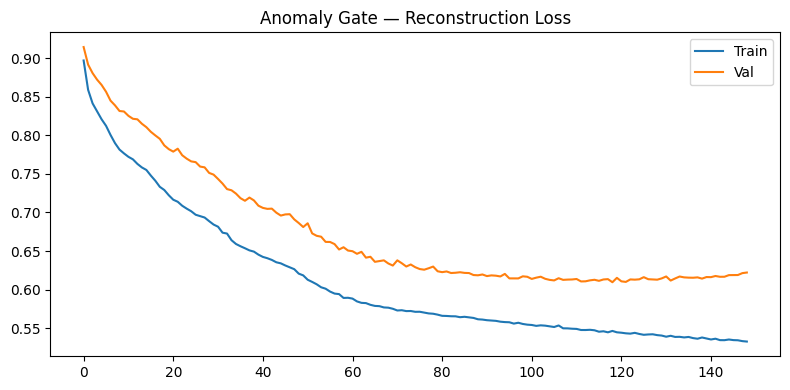

In [14]:
ae_optimizer = torch.optim.Adam(gate.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()
ae_best_loss = float('inf')
ae_patience  = 0
ae_losses, ae_val_losses = [], []

print('Training Anomaly Gate on healthy data only...')
for epoch in range(300):
    gate.train()
    batch_losses = []
    for xb, _ in ae_loader:
        ae_optimizer.zero_grad()
        loss = ae_criterion(gate(xb), xb)
        loss.backward()
        ae_optimizer.step()
        batch_losses.append(loss.item())

    gate.eval()
    with torch.no_grad():
        val_loss = ae_criterion(gate(X_ae_test), X_ae_test).item()
    ae_losses.append(np.mean(batch_losses))
    ae_val_losses.append(val_loss)

    if val_loss < ae_best_loss:
        ae_best_loss = val_loss
        torch.save(gate.state_dict(), 'best_anomaly_gate.pt')
        ae_patience = 0
    else:
        ae_patience += 1
        if ae_patience >= 30:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {np.mean(batch_losses):.6f} | Val: {val_loss:.6f}')

plt.figure(figsize=(8,4))
plt.plot(ae_losses, label='Train')
plt.plot(ae_val_losses, label='Val')
plt.title('Anomaly Gate — Reconstruction Loss')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_loss.png', dpi=150)
plt.show()

#### Compute Anomaly Thresholds

Reconstruction Error on Healthy Data:
  Mean : 0.611013
  Std  : 0.056896
  p85  : 0.657530  <- warning threshold
  p95  : 0.702180  <- anomaly threshold


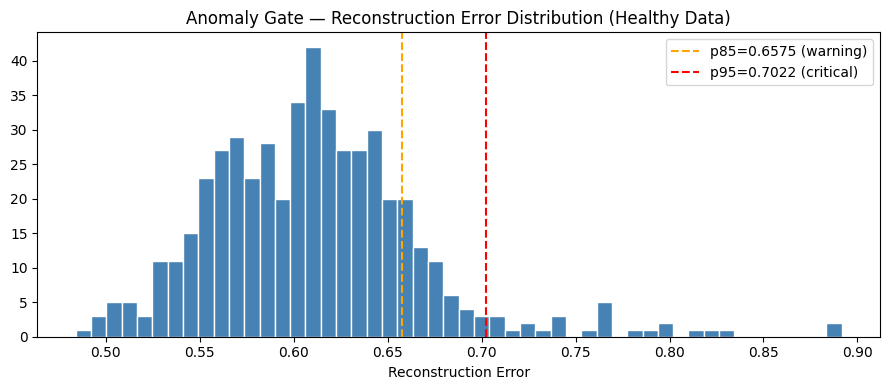

✅ Both thresholds saved (p85 warning + p95 critical).


In [15]:
gate.load_state_dict(torch.load('best_anomaly_gate.pt'))
gate.eval()
with torch.no_grad():
    recon  = gate(X_ae_test)
    errors = torch.mean(torch.abs(X_ae_test - recon), dim=(1,2)).cpu().numpy()

ANOMALY_THRESHOLD = float(np.percentile(errors, 95))
WARNING_THRESHOLD = float(np.percentile(errors, 85))

print(f'Reconstruction Error on Healthy Data:')
print(f'  Mean : {np.mean(errors):.6f}')
print(f'  Std  : {np.std(errors):.6f}')
print(f'  p85  : {WARNING_THRESHOLD:.6f}  <- warning threshold')
print(f'  p95  : {ANOMALY_THRESHOLD:.6f}  <- anomaly threshold')

plt.figure(figsize=(9,4))
plt.hist(errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(WARNING_THRESHOLD, color='orange', linestyle='--', label=f'p85={WARNING_THRESHOLD:.4f} (warning)')
plt.axvline(ANOMALY_THRESHOLD, color='red', linestyle='--', label=f'p95={ANOMALY_THRESHOLD:.4f} (critical)')
plt.title('Anomaly Gate — Reconstruction Error Distribution (Healthy Data)')
plt.xlabel('Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_thresholds.png', dpi=150)
plt.show()

thresholds = {'anomaly': ANOMALY_THRESHOLD, 'warning': WARNING_THRESHOLD}
with open('ae_thresholds.pkl','wb') as f: pickle.dump(thresholds, f)
print('✅ Both thresholds saved (p85 warning + p95 critical).')


---
## Stage 2 — FAG-TFT Classifier
### Novel Components: GRN + HierarchicalVSN + Multi-Head Attention

In [16]:
# ── FOCAL LOSS (Lin et al., 2017) ─────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class HierarchicalVSN(nn.Module):
    def __init__(self, g1_size, g2_size, g3_size, el_size, hidden_size, dropout=0.1):
        super().__init__()
        self.grn_g1 = GRN(g1_size, hidden_size, hidden_size, dropout)
        self.grn_g2 = GRN(g2_size, hidden_size, hidden_size, dropout)
        self.grn_g3 = GRN(g3_size, hidden_size, hidden_size, dropout)
        self.grn_el = GRN(el_size, hidden_size, hidden_size, dropout)
        self.sel_g1 = nn.Linear(hidden_size, hidden_size)
        self.sel_g2 = nn.Linear(hidden_size, hidden_size)
        self.sel_g3 = nn.Linear(hidden_size, hidden_size)
        self.sel_el = nn.Linear(hidden_size, hidden_size)
        self.across_grn  = GRN(hidden_size * 4, hidden_size, 4, dropout)
        self.group_merge = nn.Linear(hidden_size * 4, hidden_size)

    def forward(self, x_g1, x_g2, x_g3, x_el):
        h1 = self.grn_g1(x_g1)
        h2 = self.grn_g2(x_g2)
        h3 = self.grn_g3(x_g3)
        he = self.grn_el(x_el)
        w1 = torch.sigmoid(self.sel_g1(h1))
        w2 = torch.sigmoid(self.sel_g2(h2))
        w3 = torch.sigmoid(self.sel_g3(h3))
        we = torch.sigmoid(self.sel_el(he))
        h1, h2, h3, he = w1*h1, w2*h2, w3*h3, we*he
        concat    = torch.cat([h1, h2, h3, he], dim=-1)
        g_weights = F.softmax(self.across_grn(concat), dim=-1)
        self.group_weights = g_weights.detach().cpu()
        merged = (g_weights[:,0:1]*h1 + g_weights[:,1:2]*h2 +
                  g_weights[:,2:3]*h3 + g_weights[:,3:4]*he)
        return self.group_merge(concat) + merged


class FAG_TFT(nn.Module):
    def __init__(self, g1_size, g2_size, g3_size, el_size,
                 time_steps, num_classes, hidden_size=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.time_steps = time_steps
        self.g1_size    = g1_size
        self.g2_size    = g2_size
        self.g3_size    = g3_size
        self.el_size    = el_size
        self.vsn          = HierarchicalVSN(g1_size, g2_size, g3_size, el_size, hidden_size, dropout)
        self.lstm_encoder = nn.LSTM(hidden_size, hidden_size, 2, batch_first=True, dropout=dropout)
        self.attention    = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_norm    = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier   = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        vsn_out = []
        for t in range(self.time_steps):
            xt = x[:, t, :]
            g1 = xt[:, :self.g1_size]
            g2 = xt[:, self.g1_size:self.g1_size+self.g2_size]
            g3 = xt[:, self.g1_size+self.g2_size:self.g1_size+self.g2_size+self.g3_size]
            el = xt[:, self.g1_size+self.g2_size+self.g3_size:]
            vsn_out.append(self.vsn(g1, g2, g3, el))
        vsn_seq  = torch.stack(vsn_out, dim=1)
        lstm_out, _ = self.lstm_encoder(vsn_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)

    def get_group_importance(self):
        return self.vsn.group_weights.mean(dim=0).numpy()


tft_model = FAG_TFT(
    g1_size=len(G1_IDX), g2_size=len(G2_IDX),
    g3_size=len(G3_IDX), el_size=len(EL_IDX),
    time_steps=TIME_STEPS, num_classes=NUM_CLASSES,
    hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'FAG-TFT parameters: {sum(p.numel() for p in tft_model.parameters()):,}')

FAG-TFT parameters: 192,120


#### Train FAG-TFT — with class weights + lower LR + higher dropout

In [17]:
from sklearn.model_selection import StratifiedKFold

# ── STRATIFIED 5-FOLD CROSS-VALIDATION ────────────────────────────────
X_all_np = d['X_train_seq']
y_all_np = d['y_train_seq']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

EPOCHS = 150
PATIENCE = 25
best_overall_f1 = 0

print('Training FAG-TFT with 5-Fold CV...')
print('='*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all_np, y_all_np)):
    print(f'\n── Fold {fold+1}/5 ──')
    X_fold_train = torch.FloatTensor(X_all_np[train_idx]).to(DEVICE)
    y_fold_train = torch.LongTensor(y_all_np[train_idx]).to(DEVICE)
    X_fold_val   = torch.FloatTensor(X_all_np[val_idx]).to(DEVICE)
    y_fold_val   = torch.LongTensor(y_all_np[val_idx]).to(DEVICE)

    # Class weights for this fold
    cc = np.bincount(y_all_np[train_idx])
    cw = 1.0 / cc; cw = cw / cw.sum() * len(cc)
    w = torch.FloatTensor(cw).to(DEVICE)

    fold_model = FAG_TFT(
        g1_size=len(G1_IDX), g2_size=len(G2_IDX),
        g3_size=len(G3_IDX), el_size=len(EL_IDX),
        time_steps=TIME_STEPS, num_classes=NUM_CLASSES,
        hidden_size=64, num_heads=4, dropout=0.3
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion = FocalLoss(weight=w, gamma=2.0, label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
    loader = DataLoader(TensorDataset(X_fold_train, y_fold_train), batch_size=32, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        fold_model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(fold_model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        fold_model.eval()
        with torch.no_grad():
            val_loss = criterion(fold_model(X_fold_val), y_fold_val).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(fold_model.state_dict(), f'fag_tft_fold{fold}.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    # Evaluate fold
    fold_model.load_state_dict(torch.load(f'fag_tft_fold{fold}.pt'))
    fold_model.eval()
    with torch.no_grad():
        y_pred = np.argmax(torch.softmax(fold_model(X_fold_val), dim=1).cpu().numpy(), axis=1)
        y_true = y_fold_val.cpu().numpy()

    fold_acc = accuracy_score(y_true, y_pred)
    fold_f1  = f1_score(y_true, y_pred, average='weighted')
    fold_results.append({'acc': fold_acc, 'f1': fold_f1})
    print(f'  Fold {fold+1}: Acc={fold_acc*100:.2f}%  F1={fold_f1:.4f}')

    if fold_f1 > best_overall_f1:
        best_overall_f1 = fold_f1
        torch.save(fold_model.state_dict(), 'best_fag_tft.pt')
        print(f'  → Best model saved (F1={fold_f1:.4f})')

accs = [r['acc'] for r in fold_results]
f1s  = [r['f1'] for r in fold_results]
print(f'\n{"="*60}')
print(f'5-FOLD CV RESULTS — FAG-TFT Classifier')
print(f'{"="*60}')
print(f'Accuracy: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%')
print(f'F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')
print(f'Best fold F1: {best_overall_f1:.4f} (saved as best_fag_tft.pt)')


Training FAG-TFT with 5-Fold CV...

── Fold 1/5 ──
  Early stopping at epoch 47
  Fold 1: Acc=71.56%  F1=0.7322
  → Best model saved (F1=0.7322)

── Fold 2/5 ──
  Early stopping at epoch 51
  Fold 2: Acc=74.71%  F1=0.7623
  → Best model saved (F1=0.7623)

── Fold 3/5 ──
  Early stopping at epoch 40
  Fold 3: Acc=62.71%  F1=0.6551

── Fold 4/5 ──
  Early stopping at epoch 51
  Fold 4: Acc=73.05%  F1=0.7449

── Fold 5/5 ──
  Early stopping at epoch 55
  Fold 5: Acc=78.16%  F1=0.7938
  → Best model saved (F1=0.7938)

5-FOLD CV RESULTS — FAG-TFT Classifier
Accuracy: 72.04% ± 5.16%
F1 Score: 0.7376 ± 0.0462
Best fold F1: 0.7938 (saved as best_fag_tft.pt)


#### Evaluate FAG-TFT

FAG-TFT RESULTS
Accuracy : 98.67%
F1 Score : 0.9902
RMSE     : 0.1996
MAE      : 0.0215

                       precision    recall  f1-score   support

              Healthy       0.00      0.00      0.00         0
   High foot pressure       0.99      1.00      0.99       405
  High thread tension       0.00      0.00      0.00         0
Sewing without thread       1.00      0.98      0.99       574

             accuracy                           0.99       979
            macro avg       0.50      0.49      0.50       979
         weighted avg       0.99      0.99      0.99       979



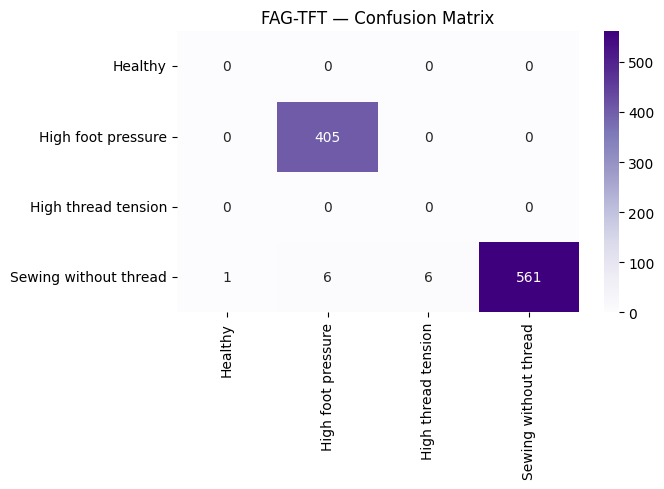

In [18]:
tft_model.load_state_dict(torch.load('best_fag_tft.pt'))
tft_model.eval()
with torch.no_grad():
    logits = tft_model(X_test)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('FAG-TFT RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('FAG-TFT — Confusion Matrix')
plt.tight_layout()
plt.savefig('fag_tft_confusion.png', dpi=150)
plt.show()

#### Interpretability — Frequency Group Importance by Breakdown Type

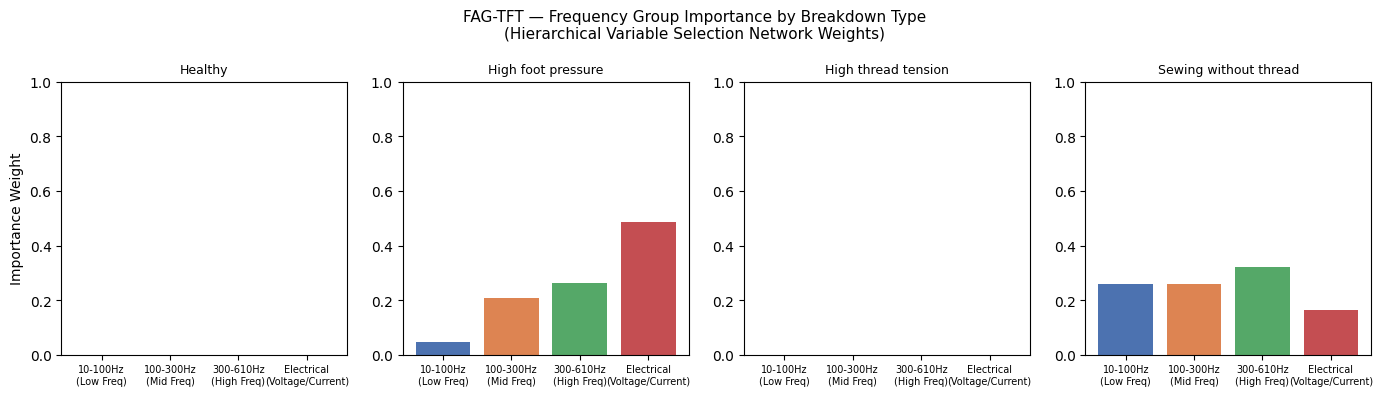

✅ Group importance plot saved.


In [19]:
group_names = ['10-100Hz\n(Low Freq)', '100-300Hz\n(Mid Freq)',
               '300-610Hz\n(High Freq)', 'Electrical\n(Voltage/Current)']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

class_importances = {cls: np.zeros(4) for cls in encoder.classes_}
class_counts_eval = {cls: 0 for cls in encoder.classes_}

tft_model.eval()
with torch.no_grad():
    for i in range(0, len(X_test), 32):
        xb = X_test[i:i+32]
        _  = tft_model(xb)
        gw = tft_model.vsn.group_weights.numpy()
        yb = y_true[i:i+len(xb)]
        for j, cls_idx in enumerate(yb):
            cls_name = encoder.classes_[cls_idx]
            class_importances[cls_name] += gw[j]
            class_counts_eval[cls_name] += 1

for cls in encoder.classes_:
    if class_counts_eval[cls] > 0:
        class_importances[cls] /= class_counts_eval[cls]

fig, axes = plt.subplots(1, len(encoder.classes_), figsize=(14, 4))
axes = np.atleast_1d(axes)  # handles single-class case
for idx, cls in enumerate(encoder.classes_):
    axes[idx].bar(group_names, class_importances[cls], color=colors)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_ylabel('Importance Weight' if idx==0 else '')
    axes[idx].tick_params(axis='x', labelsize=7)

plt.suptitle('FAG-TFT — Frequency Group Importance by Breakdown Type\n(Hierarchical Variable Selection Network Weights)', fontsize=11)
plt.tight_layout()
plt.savefig('fag_tft_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Group importance plot saved.')

#### Save All Artifacts

In [20]:
tft_results = {'model':'FAG-TFT','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae,
               'cv_acc_mean':np.mean(accs),'cv_acc_std':np.std(accs),
               'cv_f1_mean':np.mean(f1s),'cv_f1_std':np.std(f1s)}
with open('fag_tft_results.pkl','wb') as f: pickle.dump(tft_results, f)

tft_config = {
    'g1_size':len(G1_IDX), 'g2_size':len(G2_IDX),
    'g3_size':len(G3_IDX), 'el_size':len(EL_IDX),
    'time_steps':TIME_STEPS, 'num_classes':NUM_CLASSES,
    'hidden_size':64, 'num_heads':4,
    'G1_IDX':G1_IDX, 'G2_IDX':G2_IDX, 'G3_IDX':G3_IDX, 'EL_IDX':EL_IDX,
}
with open('tft_config.pkl','wb') as f: pickle.dump(tft_config, f)

print('✅ Saved: best_anomaly_gate.pt | best_fag_tft.pt | ae_thresholds.pkl | fag_tft_results.pkl | tft_config.pkl')
print(f'   Architecture: hidden=64, heads=4, lstm_layers=2, dropout=0.3')
print(f'   Final FAG-TFT Accuracy: {acc*100:.2f}%')
print(f'   CV Accuracy: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%')


✅ Saved: best_anomaly_gate.pt | best_fag_tft.pt | ae_thresholds.pkl | fag_tft_results.pkl | tft_config.pkl
   Architecture: hidden=64, heads=4, lstm_layers=2, dropout=0.3
   Final FAG-TFT Accuracy: 98.67%
   CV Accuracy: 72.04% ± 5.16%
